# Import Dependencies

In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.4/898.4 kB 20.1 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO
import torch

print('Setup complete. Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup complete. Using torch 2.4.0 _CudaDeviceProperties(name='Tesla P100-PCIE-16GB', major=6, minor=0, total_memory=16269MB, multi_processor_count=56)


# Download a Dataset With Roboflow API

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5hbzOfBhN90ffnI5InYM")
project = rf.workspace("lmm-for-cv").project("cctv-naxyo-zmeqm")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 3.4 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to cctv-1 in yolov11:: 100%|██████████| 7486/7486 [00:01<00:00, 4750.86it/s]


In [4]:
%cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['person']

roboflow:
  workspace: lmm-for-cv
  project: cctv-naxyo-zmeqm
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/lmm-for-cv/cctv-naxyo-zmeqm/dataset/1

# Define Model Configuration and Architecture

In [5]:
model = YOLO("/content/yolo11m.pt")

100%|██████████| 38.8M/38.8M [00:00<00:00, 299MB/s]


# Train Custom YOLOv11

- **imgsz:** define input image size
- **batch:** determine batch size
- **epochs:** define the number of training epochs. 
- **data:** set the path to our yaml fraining

In [6]:
model.train(data = "/kaggle/working/cctv-1/data.yaml", batch = 32, epochs = 40, imgsz= 640, device=0)

Ultralytics 8.3.43 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=/content/yolo11m.pt, data=/kaggle/working/cctv-1/data.yaml, epochs=40, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_con

100%|██████████| 755k/755k [00:00<00:00, 21.2MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1      1856  ultralytics.nn.modules.conv.Conv             [3, 64, 3, 2]                 
  1                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  2                  -1  1    111872  ultralytics.nn.modules.block.C3k2            [128, 256, 1, True, 0.25]     
  3                  -1  1    590336  ultralytics.nn.modules.conv.Conv             [256, 256, 3, 2]              
  4                  -1  1    444928  ultralytics.nn.modules.block.C3k2            [256, 512, 1, True, 0.25]     
  5                  -1  1   2360320  ultralytics.nn.modules.conv.Conv             [512, 512, 3, 2]              
  6                  -1  1   1380352  ultralytics.nn.modules.block.C3k2            [512, 512, 1, True]           
  7                  -1  1   2360320  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 90.6MB/s]


AMP: checks passed ✅


...

                   all        526       1678      0.896      0.783      0.868       0.58



40 epochs completed in 1.568 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 40.5MB
Optimizer stripped from runs/detect/train/weights/best.pt, 40.5MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.43 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:07<00:00,  1.19it/s]


                   all        526       1678      0.896      0.782      0.869      0.581
Speed: 0.1ms preprocess, 8.7ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79c1519cefe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

# Evaluation Custom YOLOv11

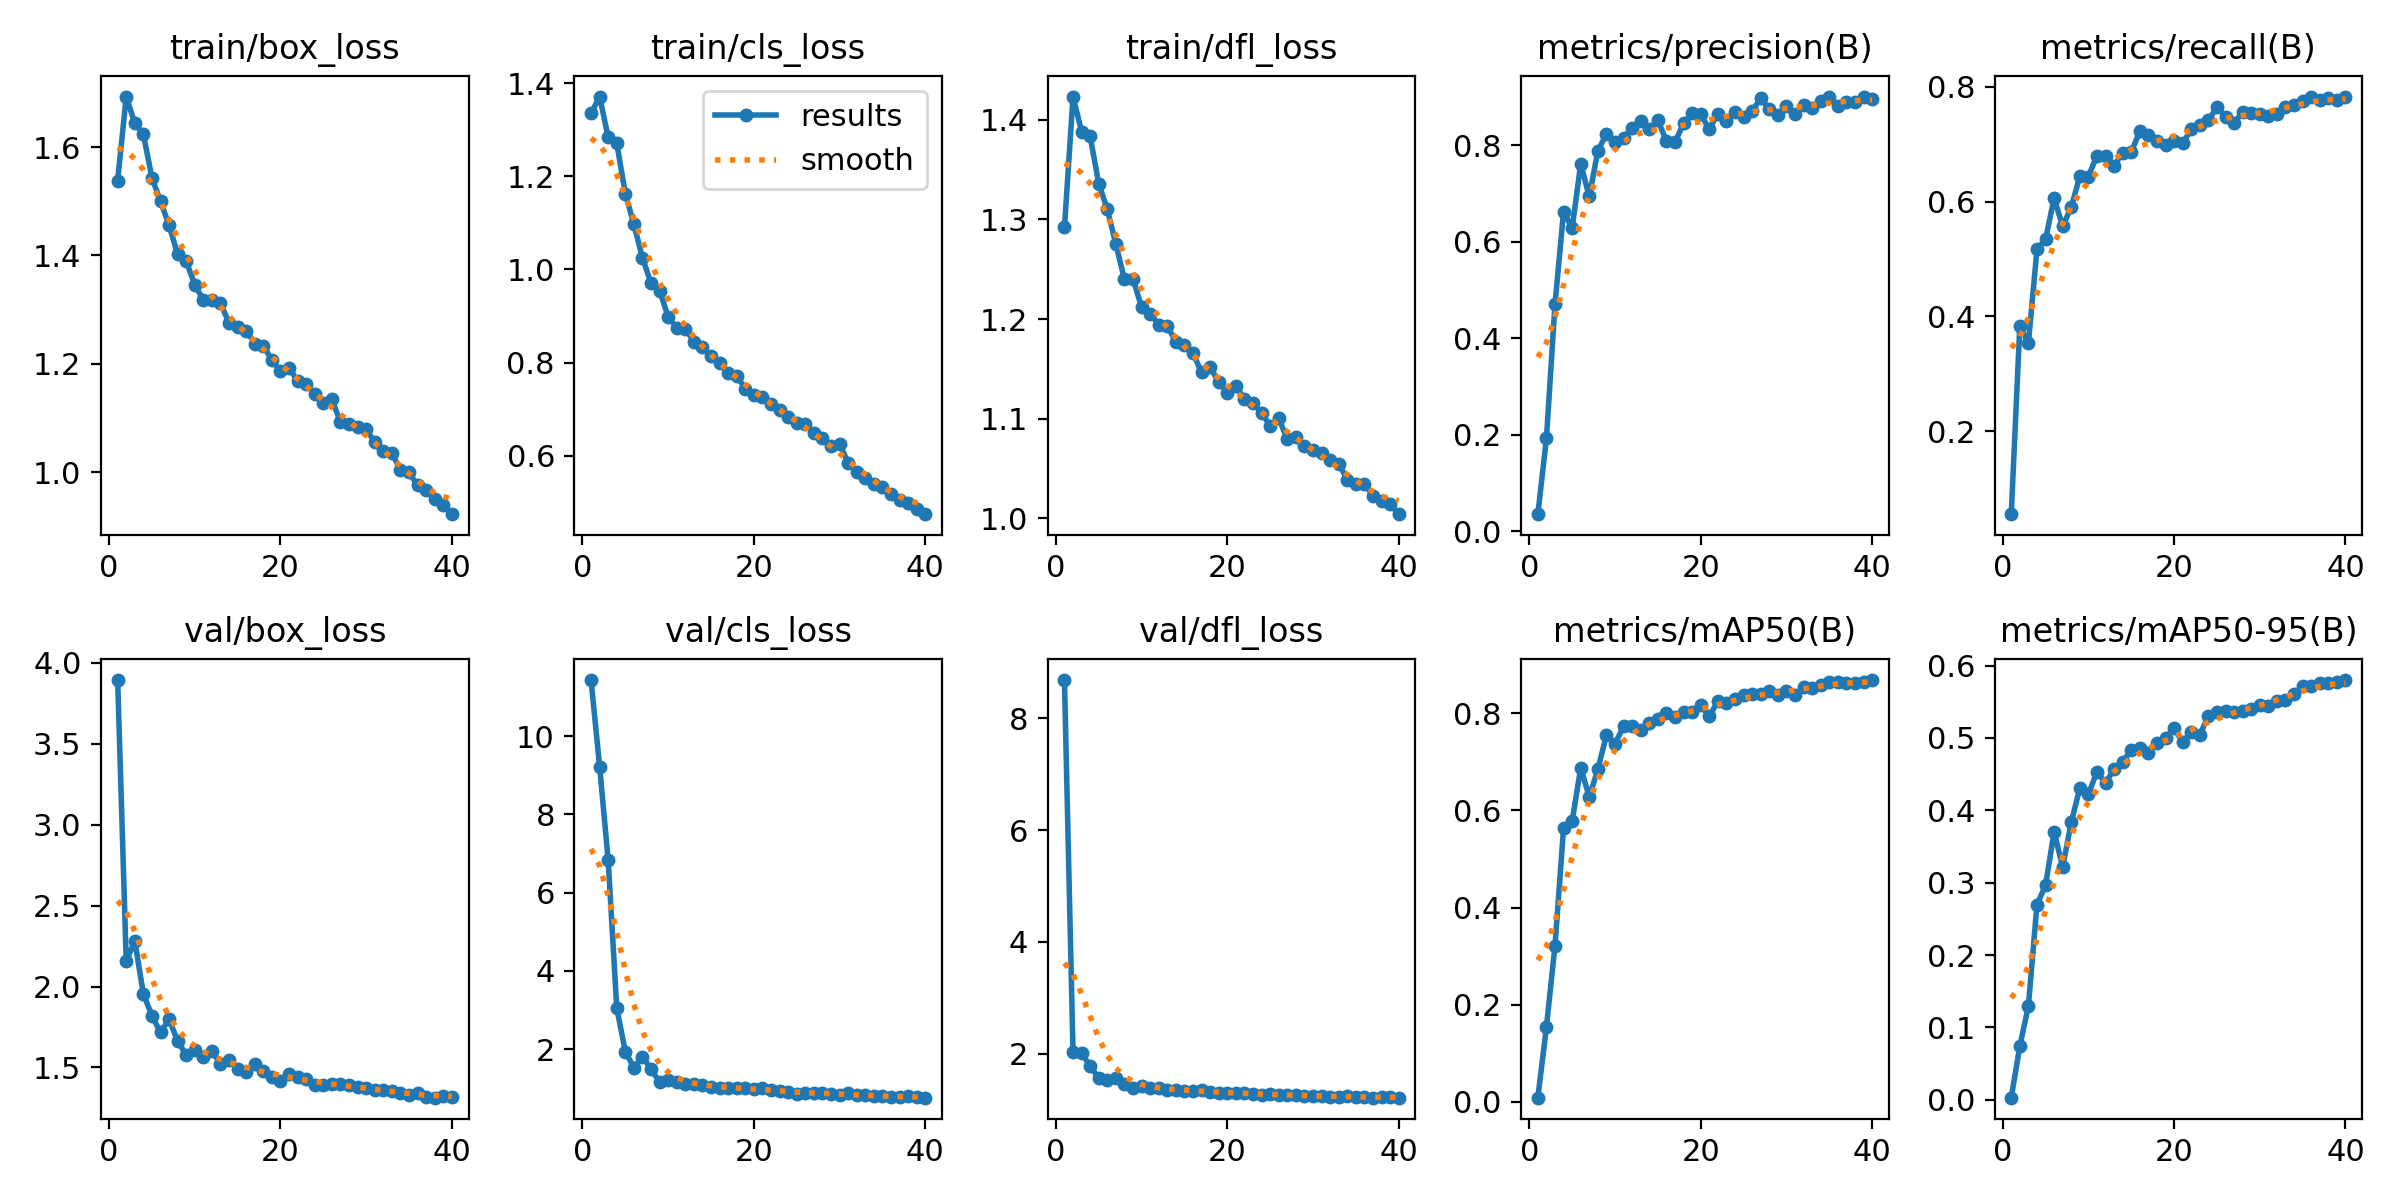

In [7]:
from IPython.display import Image  # plot results.txt as results.png
Image(filename='/kaggle/working/runs/detect/train/results.png', width=1000)  # view results.png

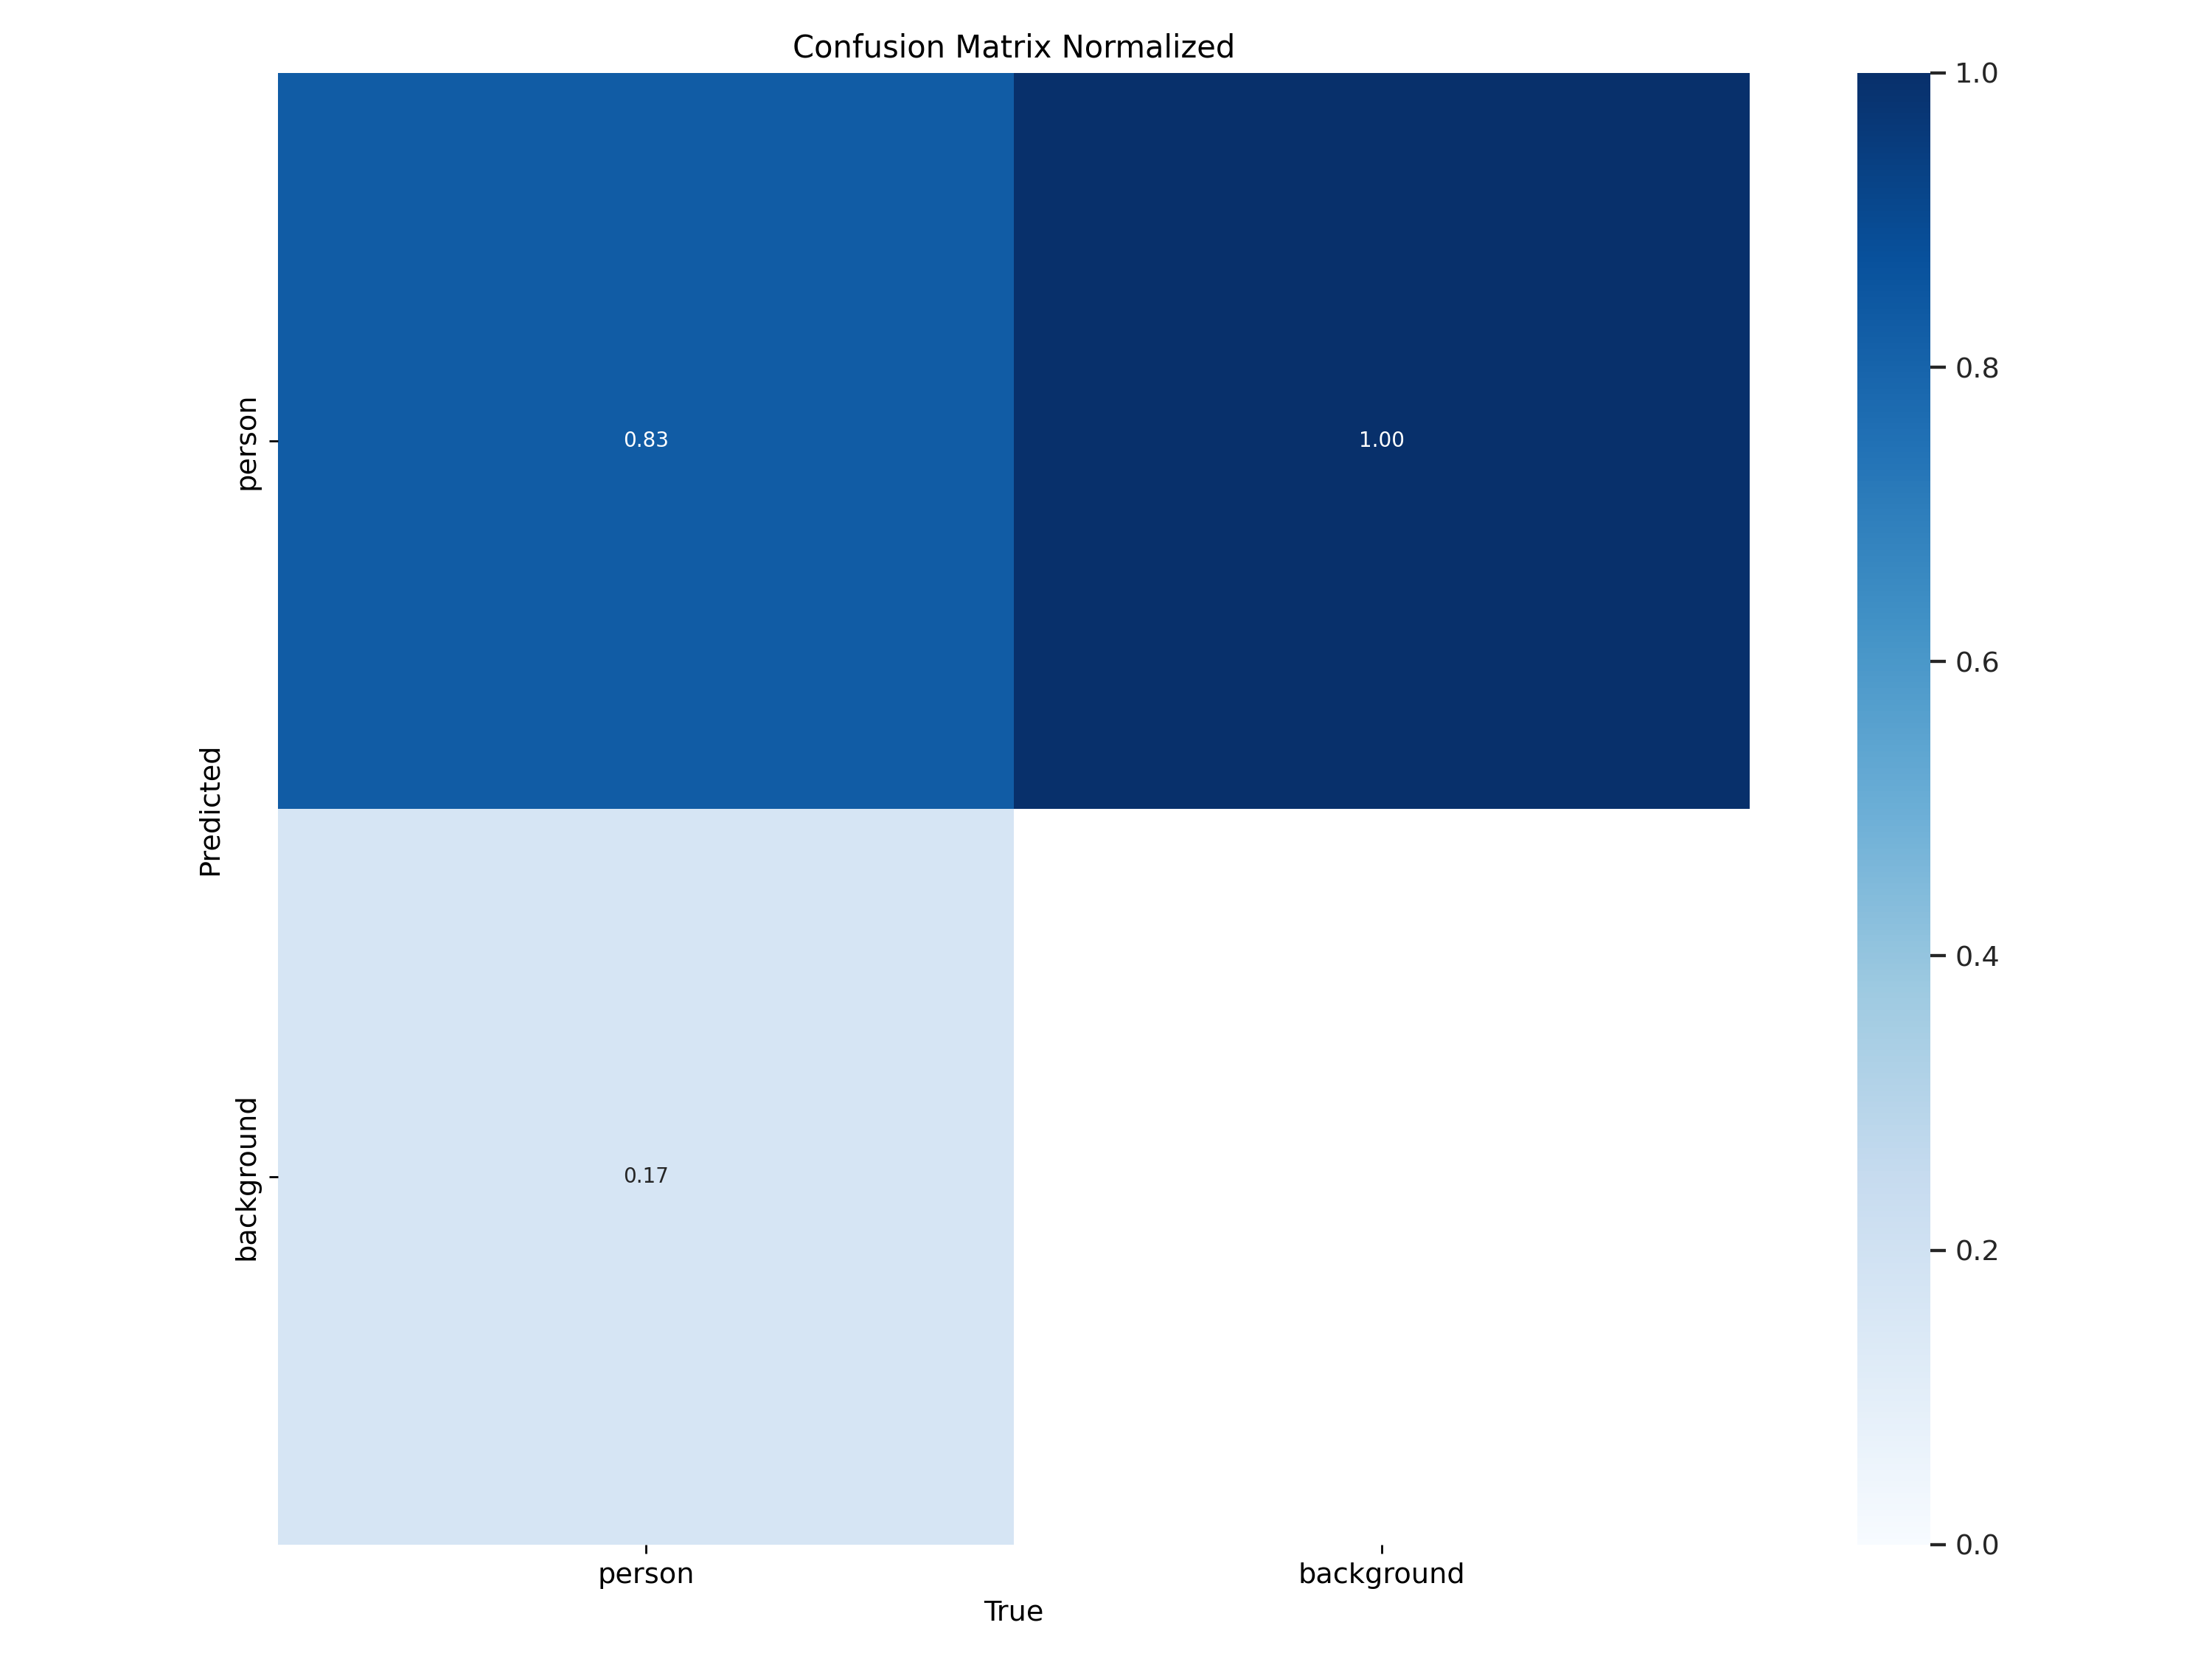

In [8]:
Image(filename='/kaggle/working/runs/detect/train/confusion_matrix_normalized.png', width=1000)  # view results.png

# Visualize Our Training Data with Labels

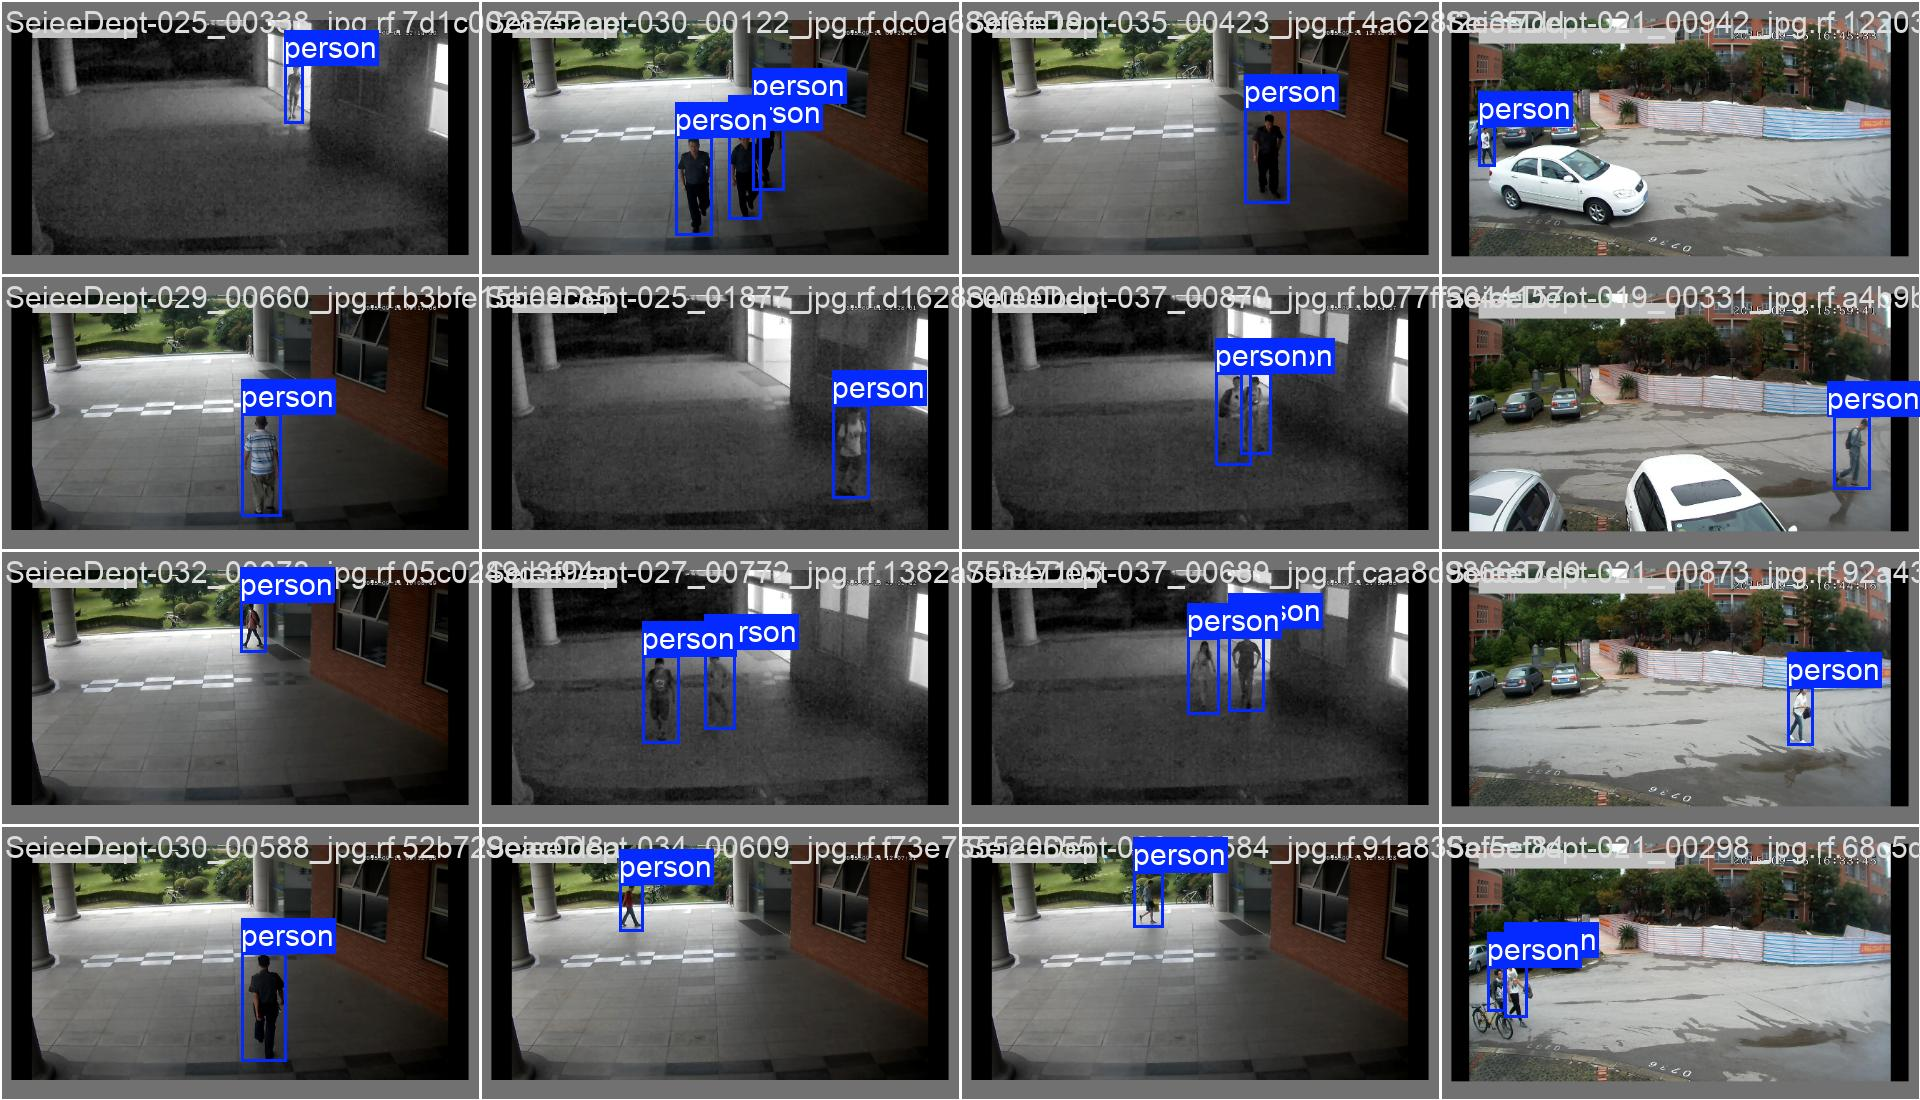

In [9]:
Image(filename='/kaggle/working/runs/detect/train/val_batch0_labels.jpg', width=900)

GROUND TRUTH AUGMENTED TRAINING DATA:


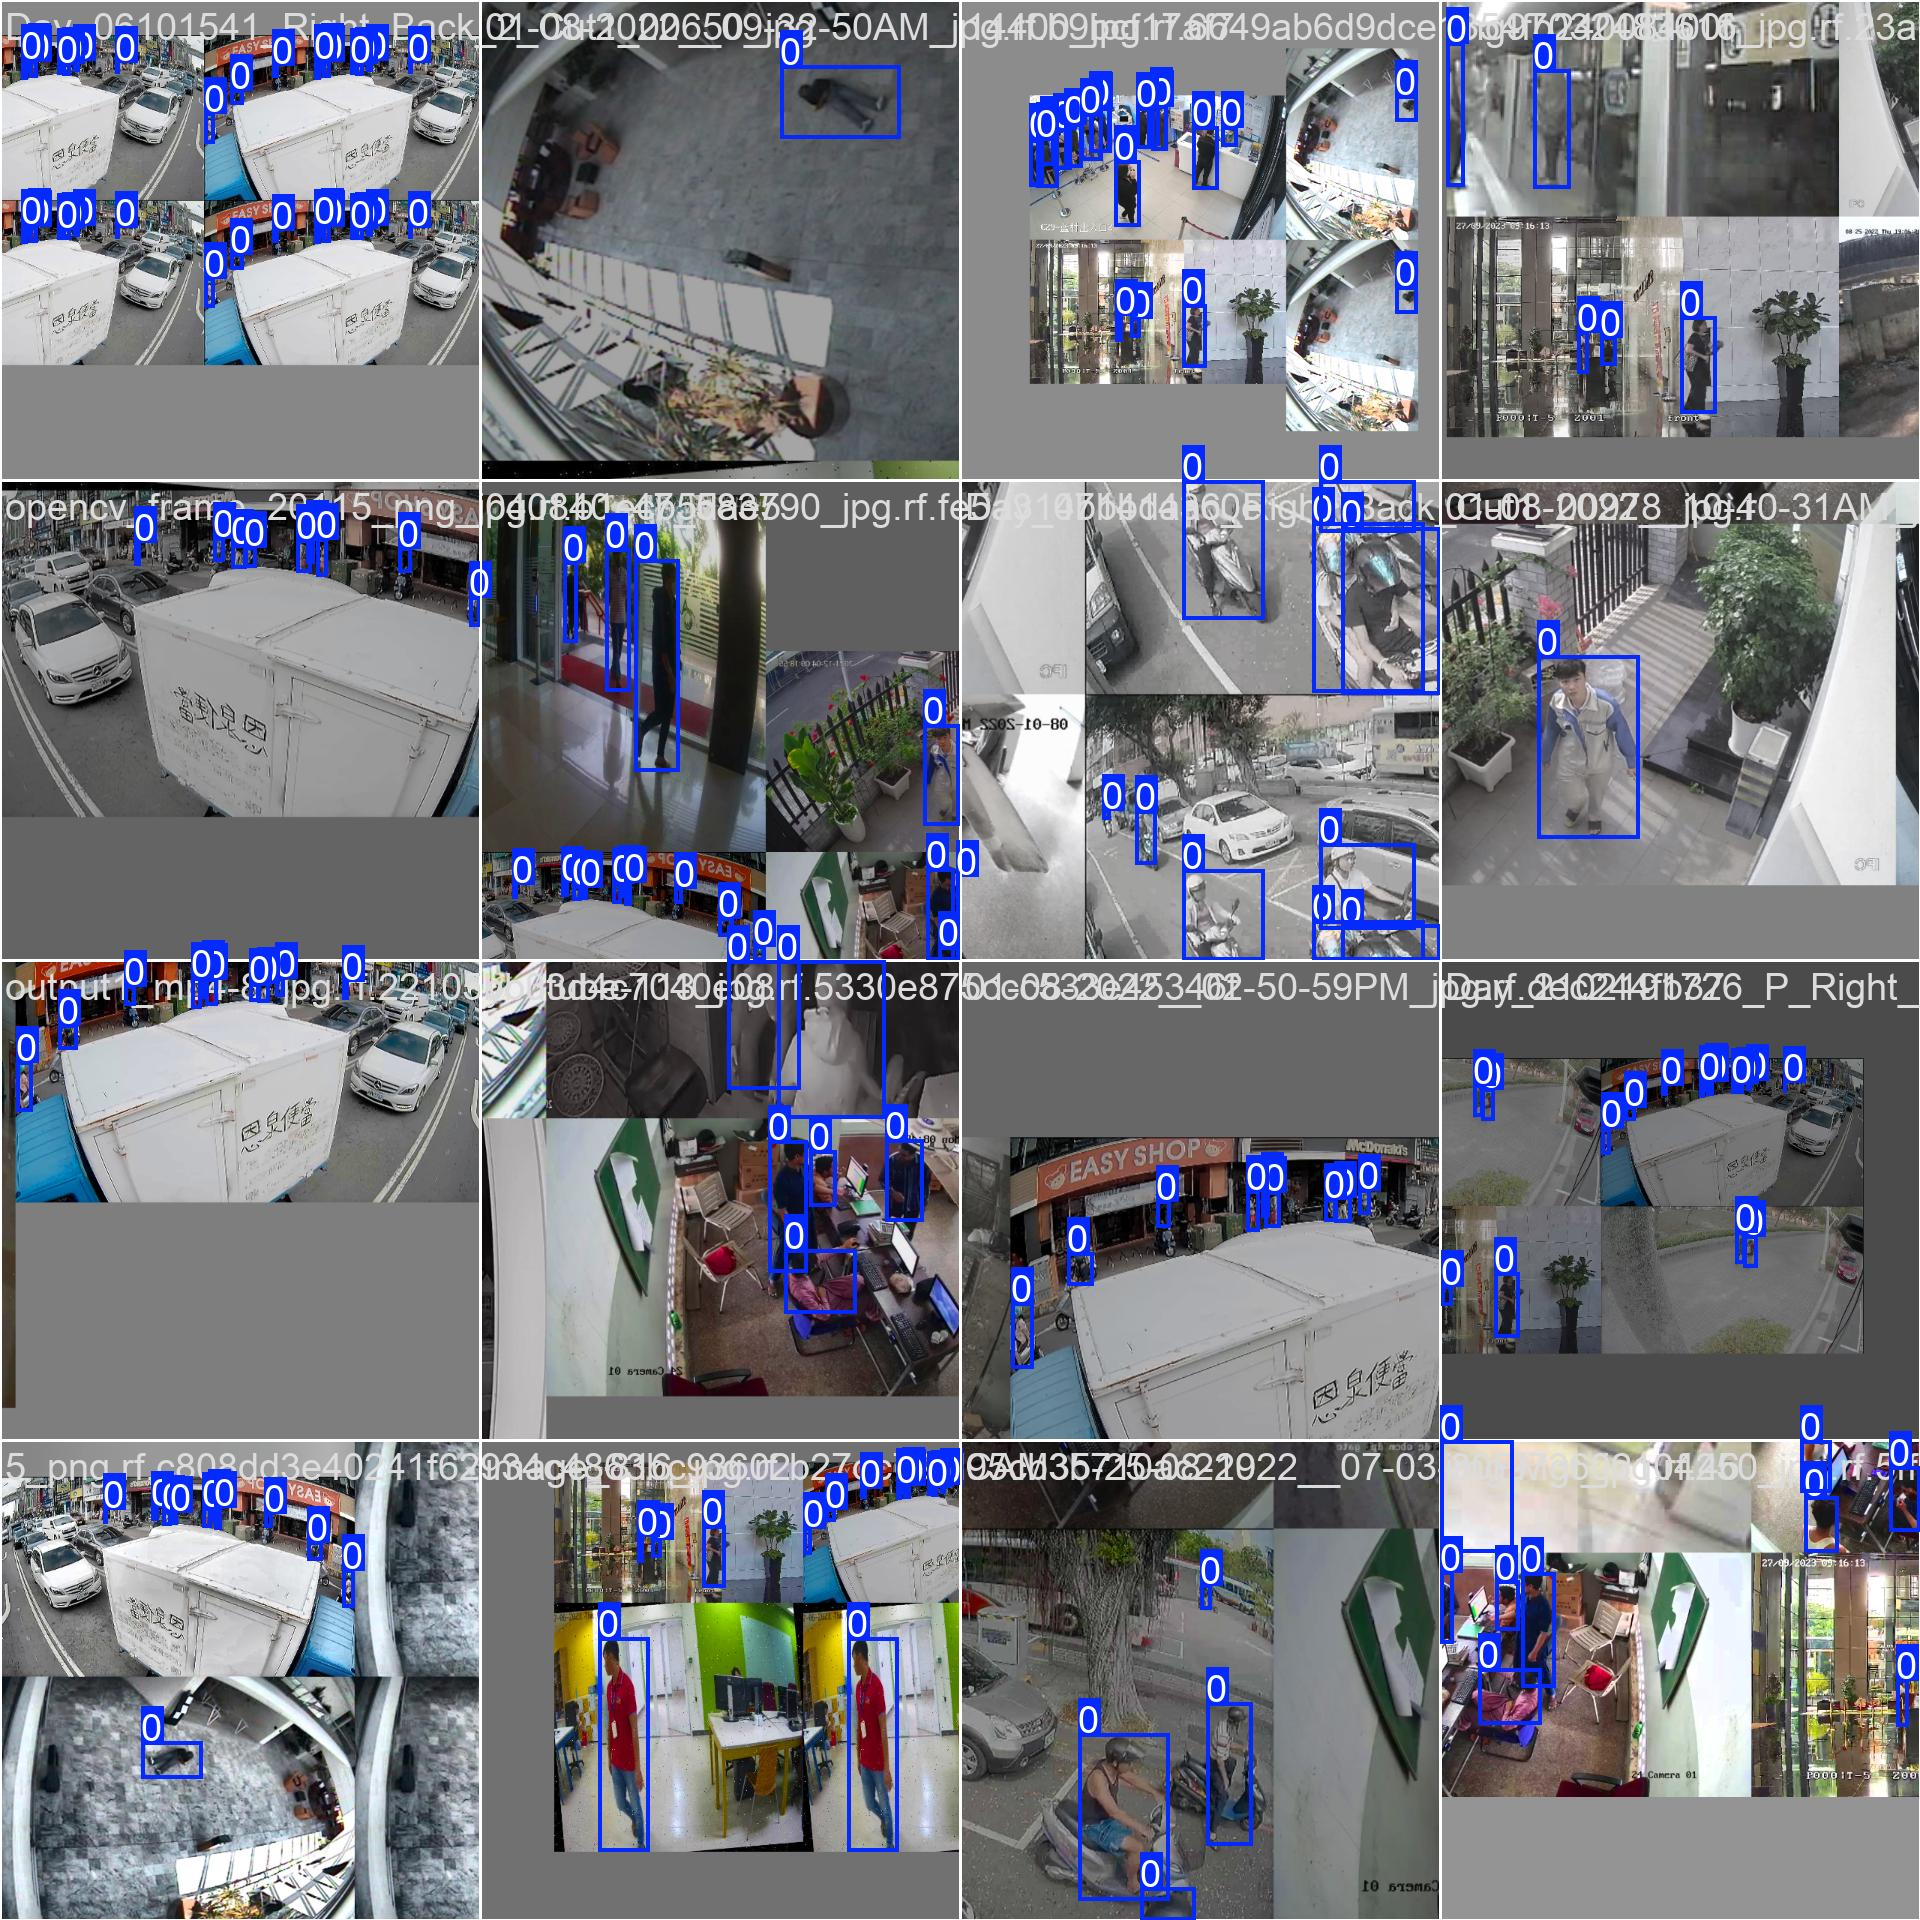

In [10]:
# print out an augmented training example
print("GROUND TRUTH AUGMENTED TRAINING DATA:")
Image(filename='/kaggle/working/runs/detect/train/train_batch0.jpg', width=900)

# Run Inference With Trained Weights

In [11]:
custom_model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

In [12]:
custom_model.predict(source = "/kaggle/working/cctv-1/test/images", save=True, conf=0.6)


image 1/151 /kaggle/working/cctv-1/test/images/00381_jpg.rf.96b1385579ad5e62d51d2cf0da26a562.jpg: 480x640 1 person, 51.0ms
image 2/151 /kaggle/working/cctv-1/test/images/00390_jpg.rf.efbb4b07cc7ffbe7dd8b94cd6855fa65.jpg: 480x640 1 person, 13.2ms
image 3/151 /kaggle/working/cctv-1/test/images/00420_jpg.rf.654900b16fa9f7ca0640b20113e38856.jpg: 480x640 1 person, 13.2ms
image 4/151 /kaggle/working/cctv-1/test/images/00505_jpg.rf.92b3c11d44620cfeba2e1cbdf623f4e5.jpg: 480x640 2 persons, 13.1ms
image 5/151 /kaggle/working/cctv-1/test/images/00539_jpg.rf.b759442bed9af8d166e8d6175d13f5fa.jpg: 480x640 1 person, 13.4ms
image 6/151 /kaggle/working/cctv-1/test/images/00566_jpg.rf.c0a0fae74f6a654e71e4f1fdbe81325c.jpg: 480x640 1 person, 13.1ms
image 7/151 /kaggle/working/cctv-1/test/images/00630_jpg.rf.baac5cdeec7efba0dae3f878010da48a.jpg: 480x640 1 person, 13.1ms
image 8/151 /kaggle/working/cctv-1/test/images/00764_jpg.rf.70b2a29995fea3c17edb5956f36bcc17.jpg: 480x640 1 person, 13.3ms
image 9/151 /k

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        ...,
 
        [[52, 52, 52],
         [54, 54, 54],
         [56, 56, 56],
         ...,
         [48, 48, 48],
         [46, 46, 46],
         [45, 45, 45]],
 
        [[49, 49, 49],
         [51, 51, 51],
         [53, 53, 53],
         ...,
         [48, 48, 48],
         [46, 46, 46],
         [44, 44, 44]],
 
        [[48, 48, 48],
    

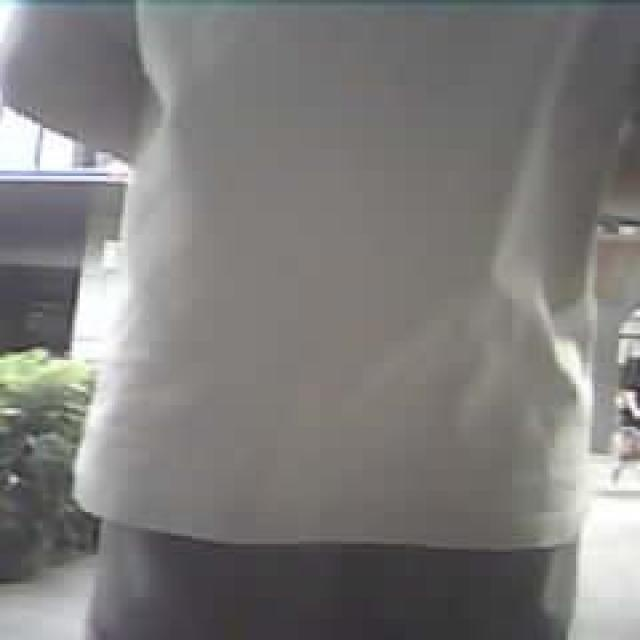

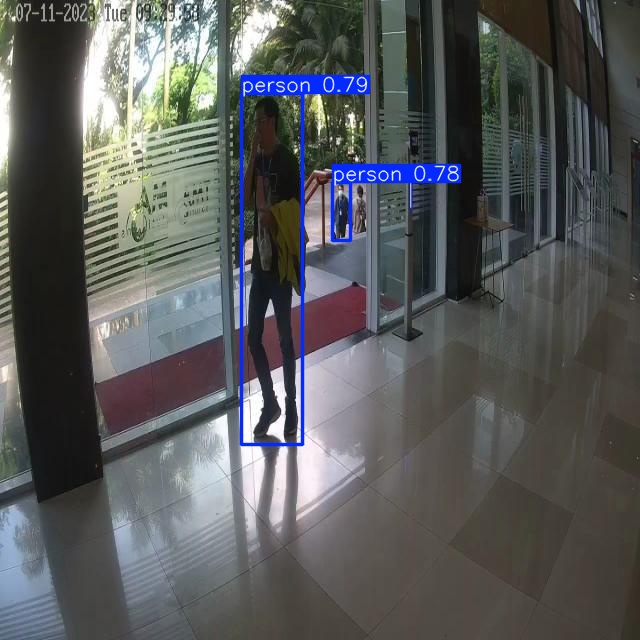

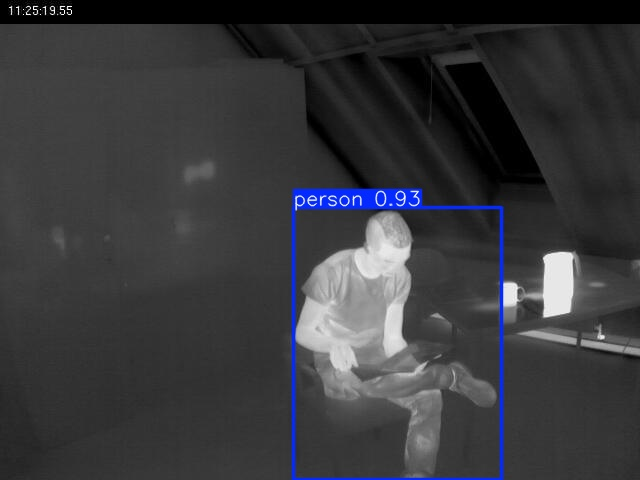

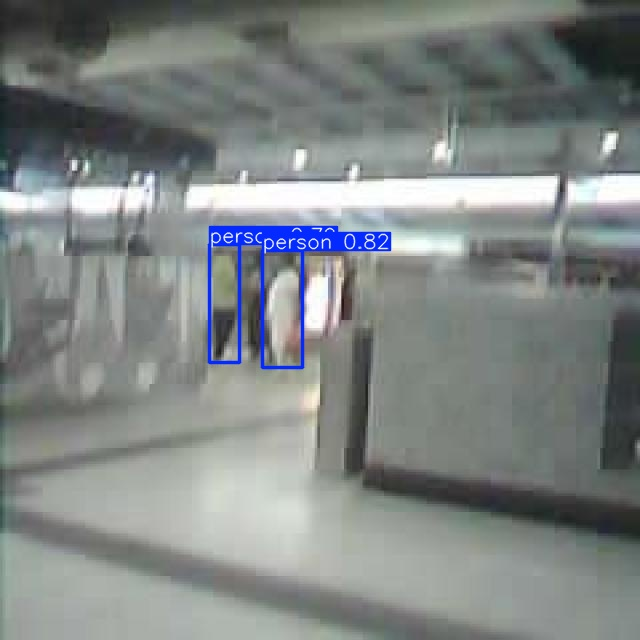

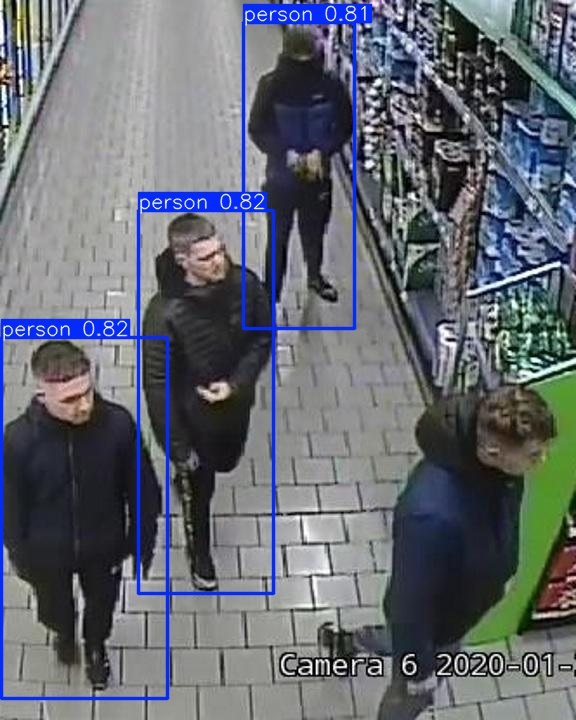

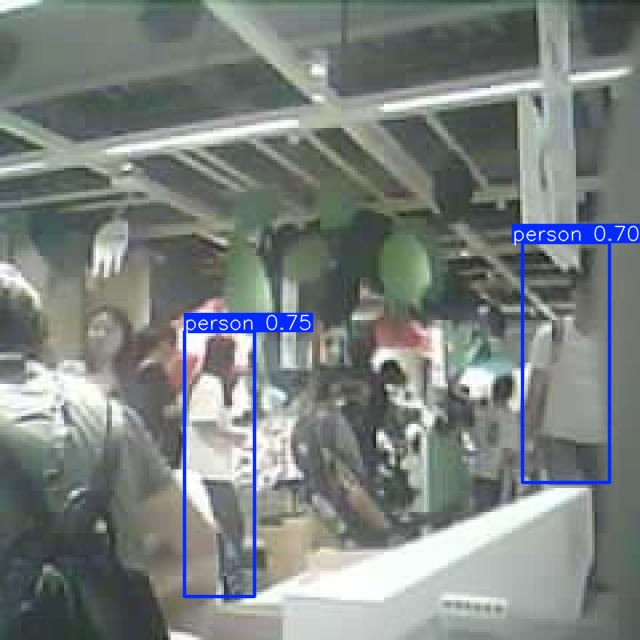

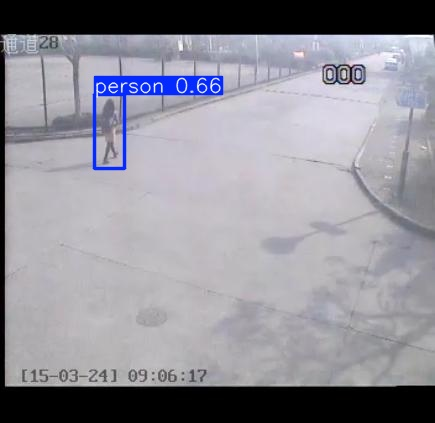

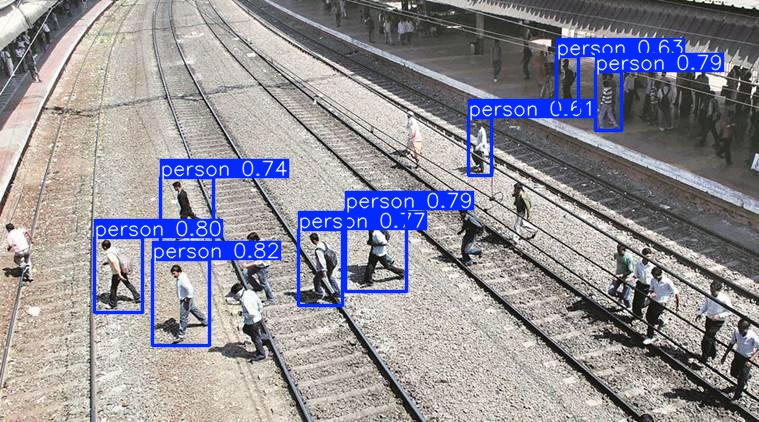

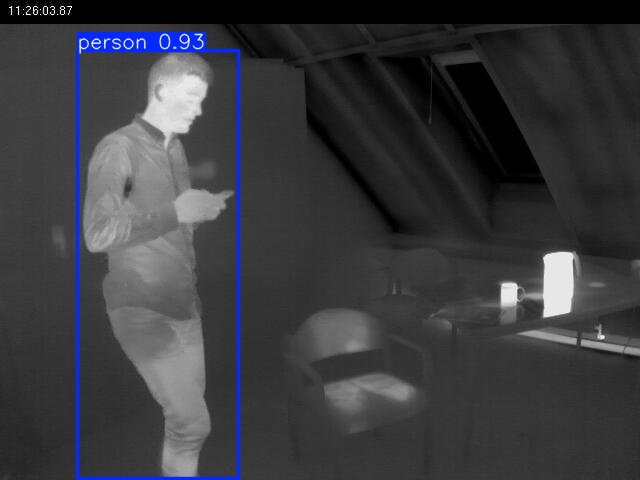

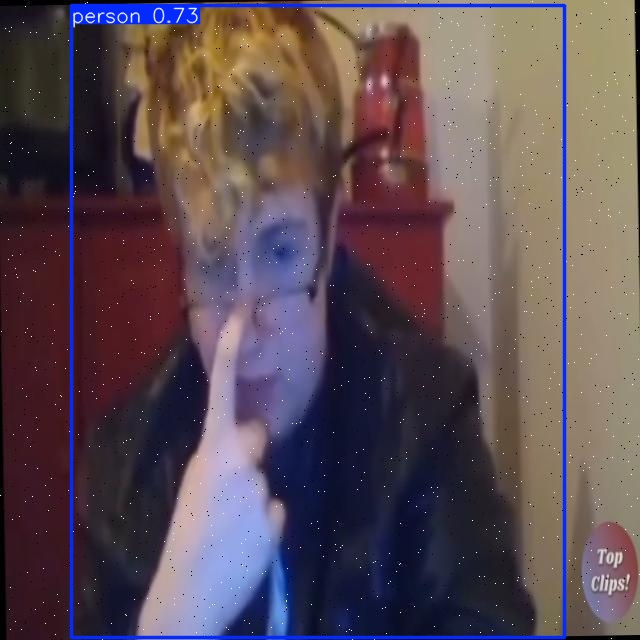

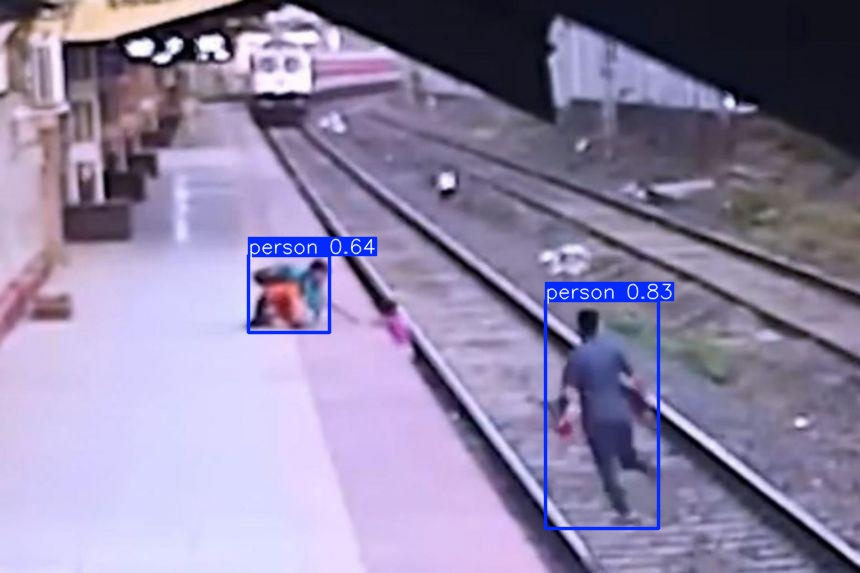

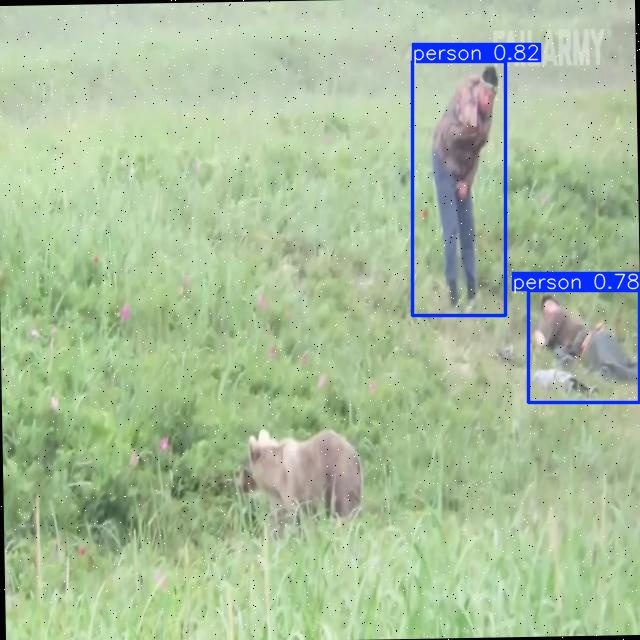

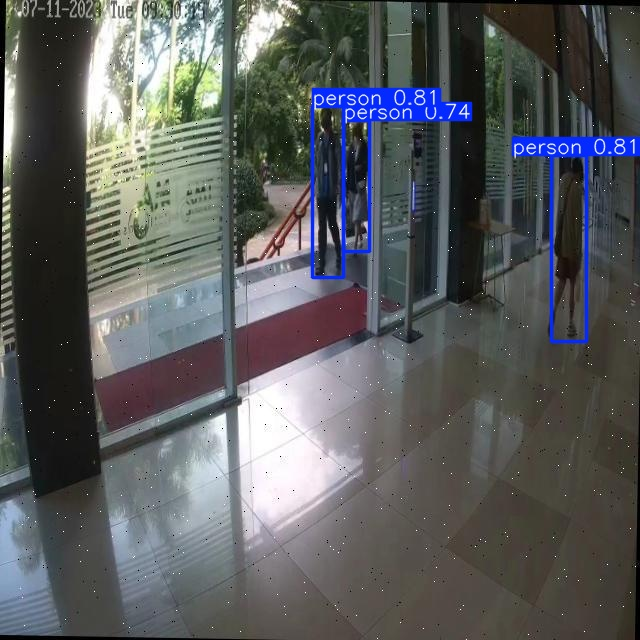

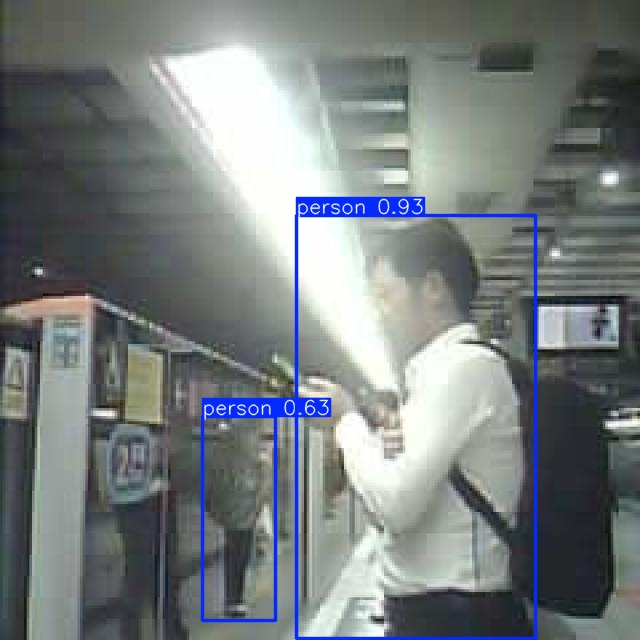

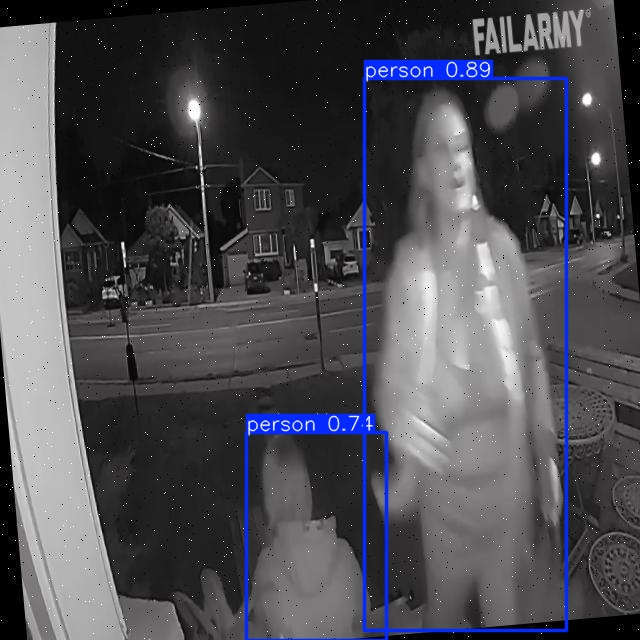

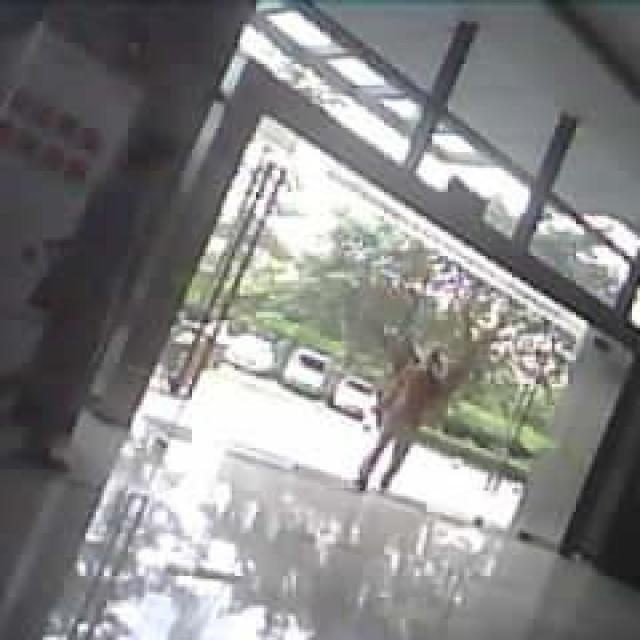

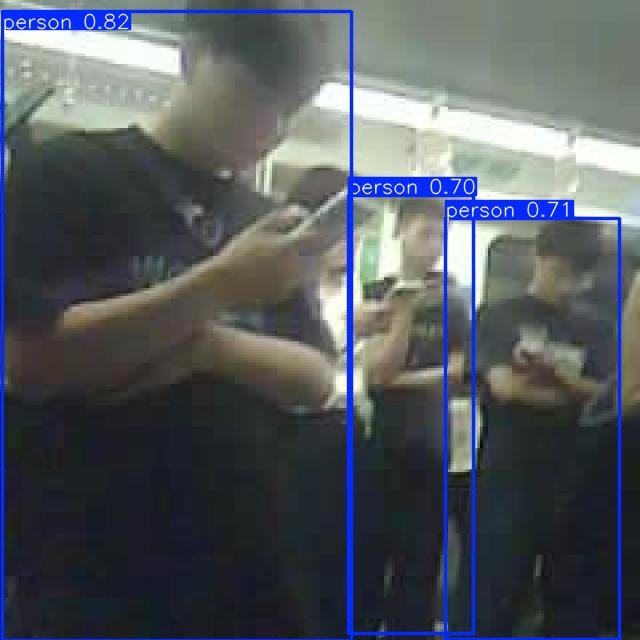

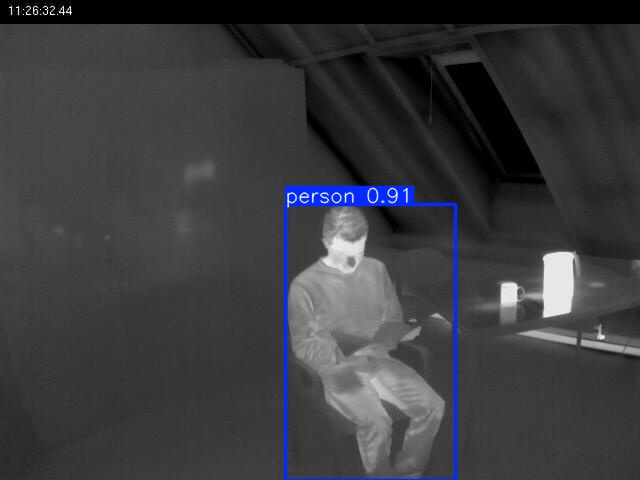

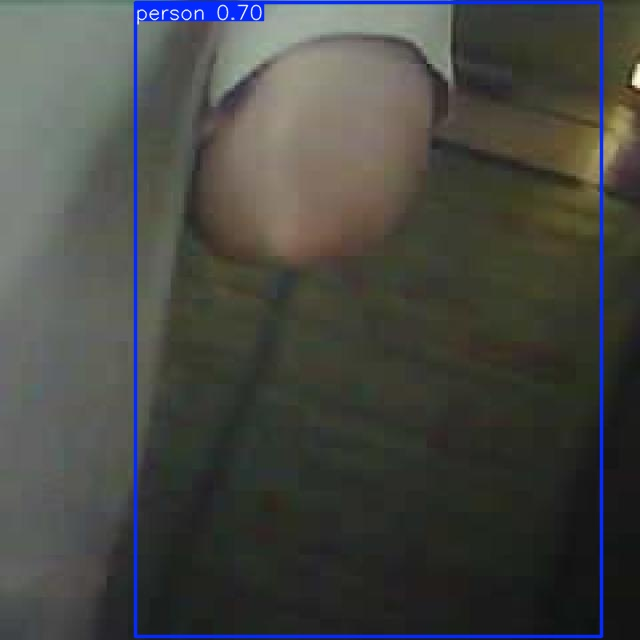

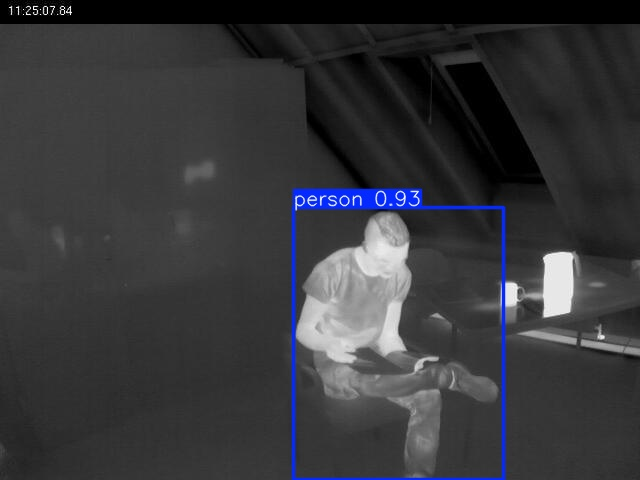

In [13]:
import glob
from IPython.display import Image, display

for imageName in glob.glob('/kaggle/working/runs/detect/predict/*.jpg')[:20]: #assuming JPG
    display(Image(filename=imageName))

# Save Model

In [14]:
!zip -r /kaggle/working/custom_yolov11.zip /kaggle/working/runs

os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.


  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/ (stored 0%)
  adding: kaggle/working/runs/detect/predict/img9736025802_jpg.rf.c915c0e1bc2dfb690761f38fde590e11.jpg (deflated 13%)
  adding: kaggle/working/runs/detect/predict/output_mp4-25_jpg.rf.fe847337038f304a36ebe26c981b0253.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/predict/00566_jpg.rf.c0a0fae74f6a654e71e4f1fdbe81325c.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/predict/img970324131140_jpg.rf.ef6f236535a4f793df182dddcd98f130.jpg (deflated 6%)
  adding: kaggle/working/runs/detect/predict/CaughtonCameraTheftfromshop-03-02-20-jpg-gallery_jpg.rf.dacea45a3b6de04d08ac4f2aaa8526d8.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/predict/img96579629246_jpg.rf.2e620ae7629726e7da0c58486b8ea301.jpg (deflated 6%)
  adding: kaggle/working/runs/detect/predict/CrossRoad-001_00019_jpg.rf.6181fee3d688d3edec0f2d10c16e71b1.jpg (deflat